Extracting parameters from D:\Data_at_IITJ\sub010\EEG\sub010-exp2.vhdr...
Setting channel info structure...


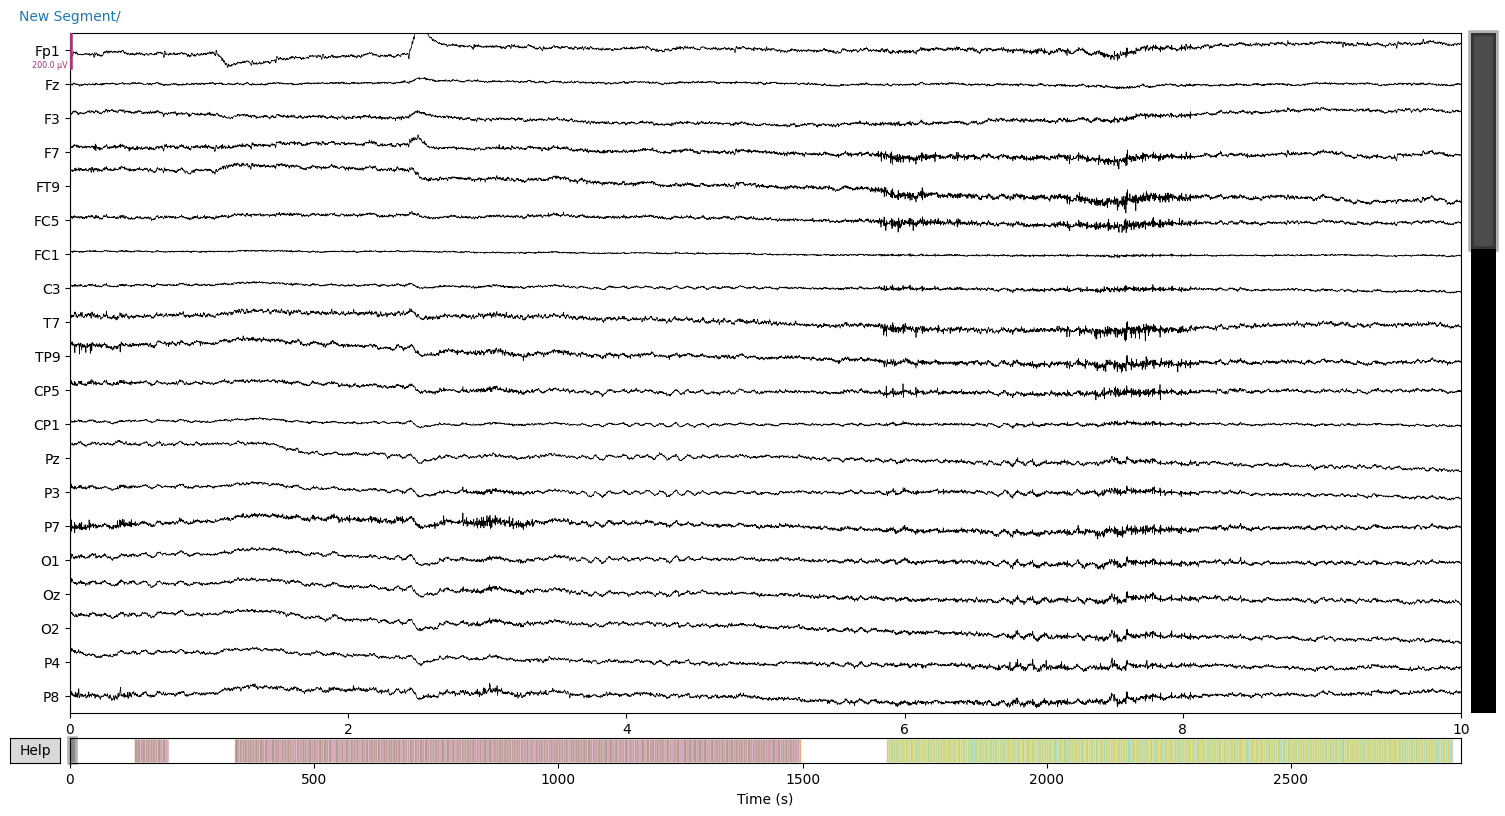

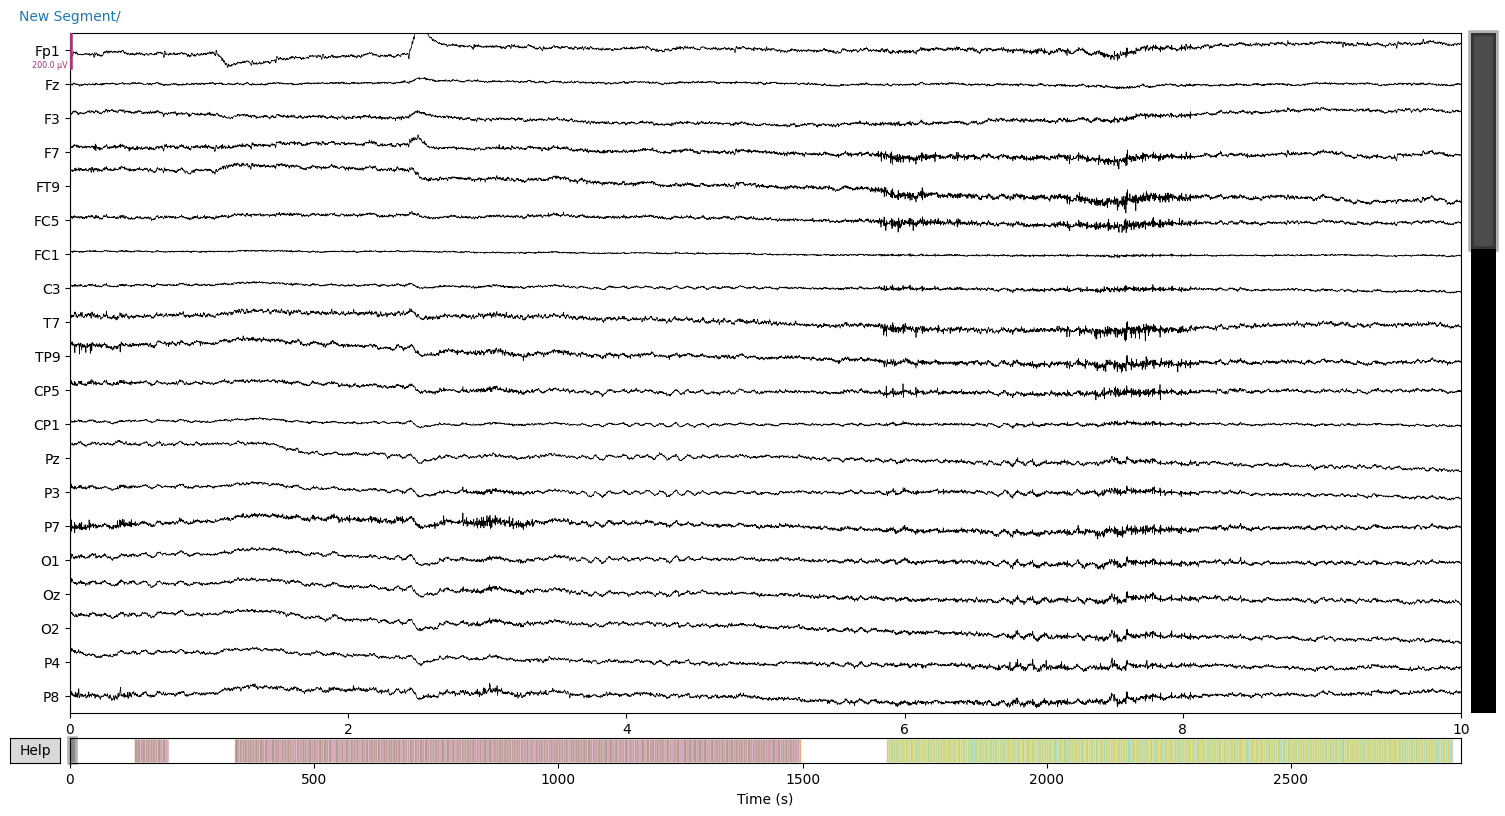

In [43]:
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd

import mne


raw_file = r"D:\Data_at_IITJ\sub010\EEG\sub010-exp2.vhdr"
raw = mne.io.read_raw_brainvision(raw_file, preload=False)

raw.plot(scalings=dict(eeg=1e-4))


In [44]:
print(raw)
print(raw.info)

<RawBrainVision | Sub010-exp2.eeg, 63 x 2848120 (2848.1 s), ~55 kB, data not loaded>
<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, ...
 chs: 63 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 280.0 Hz
 meas_date: 2024-06-08 14:00:28 UTC
 nchan: 63
 projs: []
 sfreq: 1000.0 Hz
>


Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\CSNDLab\AppData\Local\Temp\ipykernel_12648\3186301473.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
c:\Users\CSNDLab\.conda\envs\EEG_analysis\Lib\site-packages\mne\viz\utils.py:167: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


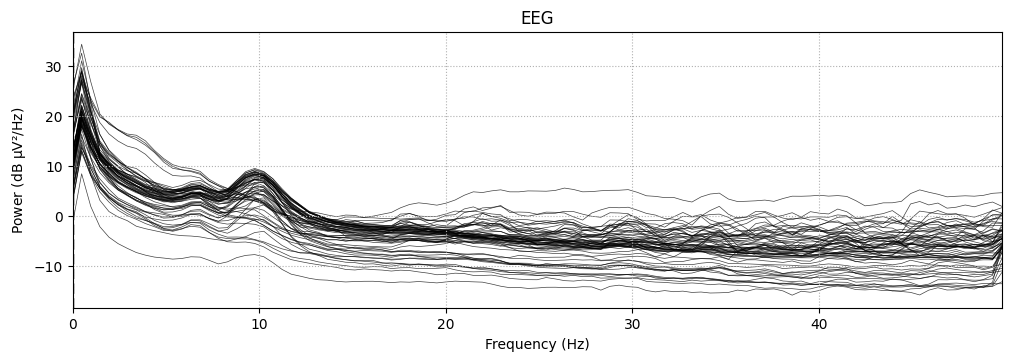

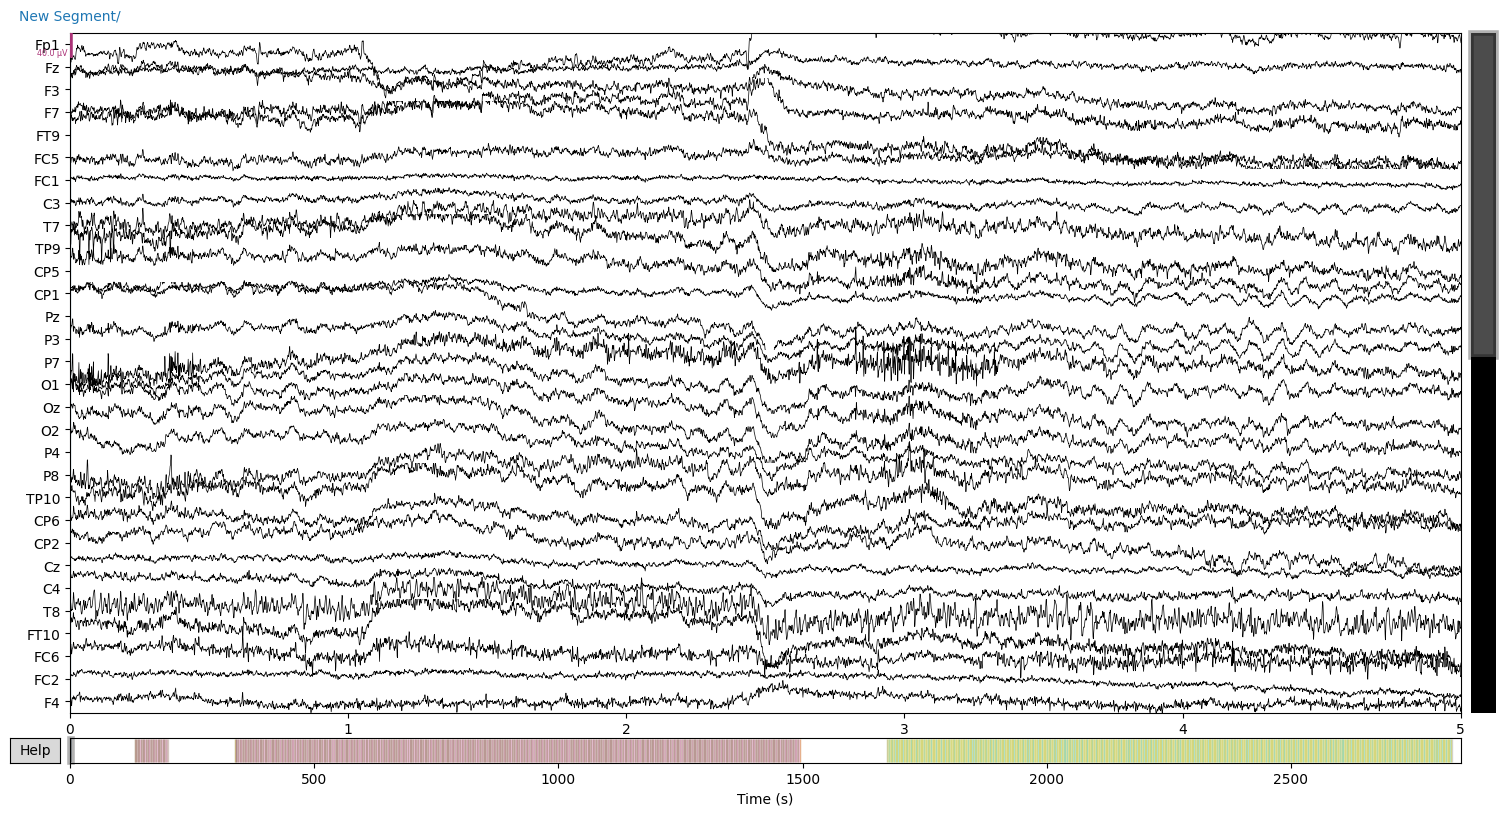

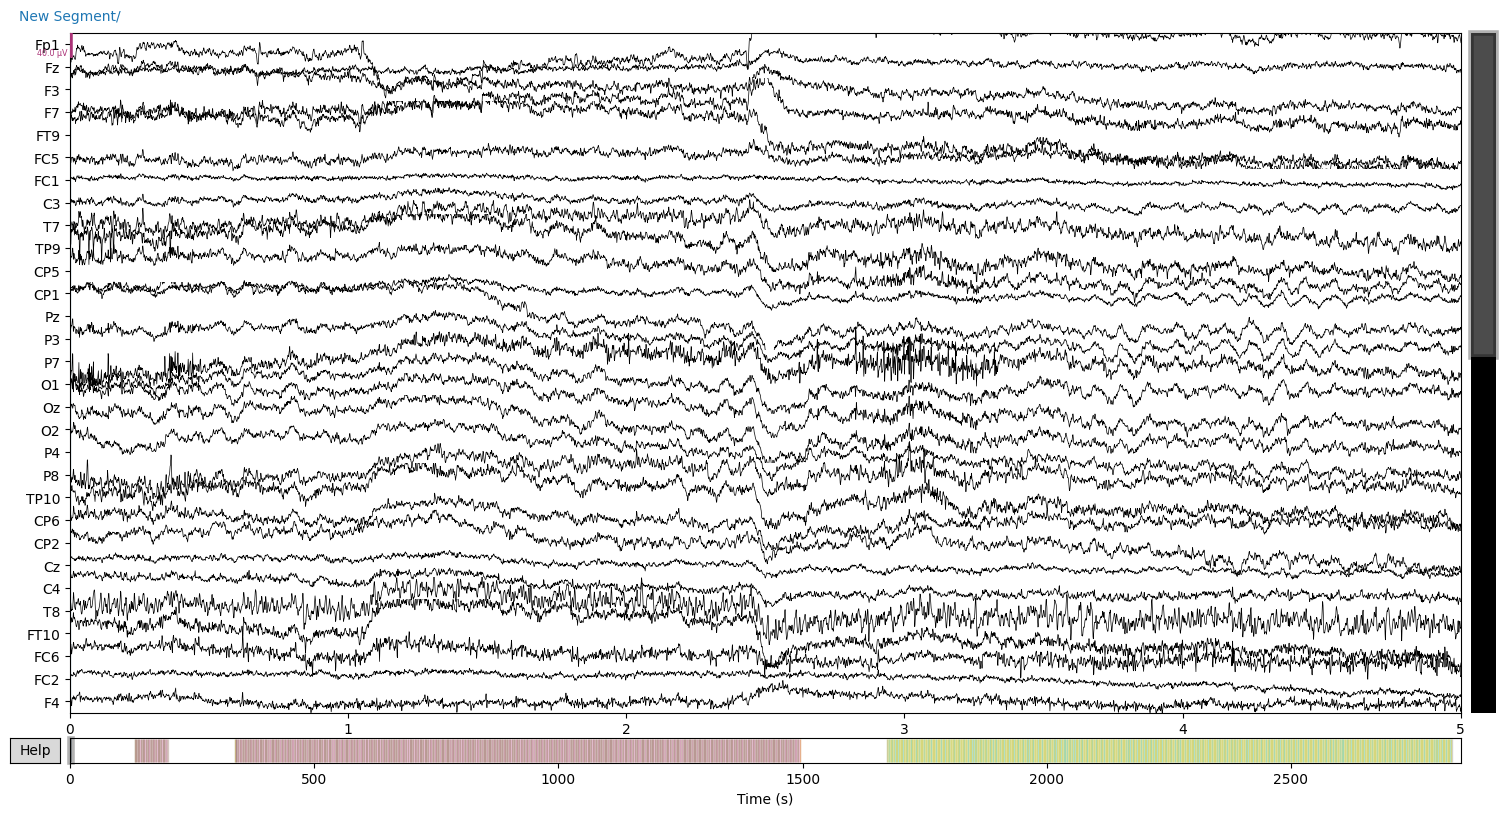

In [45]:
raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
raw.plot(duration=5, n_channels=30)

In [46]:
events,event_dict = mne.events_from_annotations(raw)
print(event_dict)

Used Annotations descriptions: ['New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25']


{'New Segment/': 99999, 'Stimulus/S 11': 11, 'Stimulus/S 12': 12, 'Stimulus/S 13': 13, 'Stimulus/S 14': 14, 'Stimulus/S 15': 15, 'Stimulus/S 21': 21, 'Stimulus/S 24': 24, 'Stimulus/S 25': 25}


Not setting metadata
952 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 952 events and 1001 original time points ...
0 bad epochs dropped


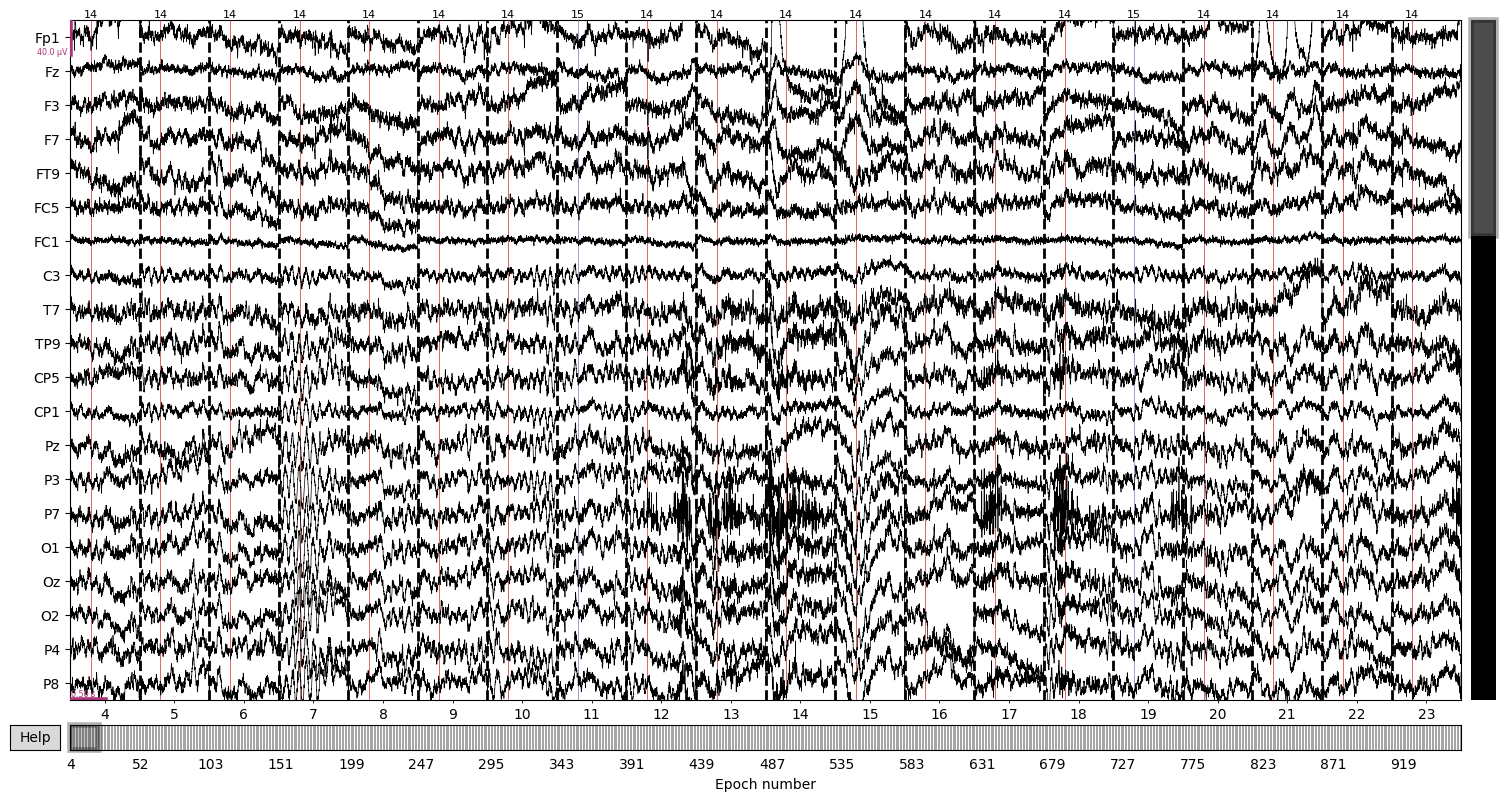

In [47]:
B1_epochs = mne.Epochs(raw, events, event_id=[14,15], tmin=-0.3, tmax=0.7, preload=True)
fig = B1_epochs.plot(events=events
                  )

In [48]:
devi_eps = B1_epochs['15'].average()
sta_eps = B1_epochs["14"].average()

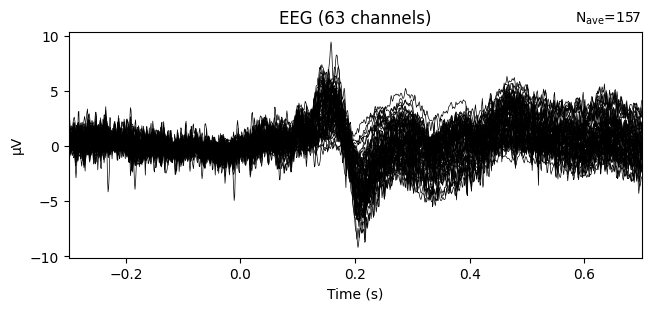

C:\Users\CSNDLab\AppData\Local\Temp\ipykernel_12648\3372033010.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig2 = sta_eps.plot(spatial_colors=True)


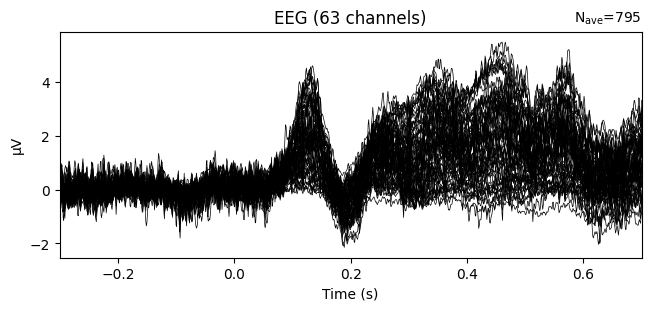

In [49]:
fig1 = devi_eps.plot()
fig2 = sta_eps.plot(spatial_colors=True)

C:\Users\CSNDLab\AppData\Local\Temp\ipykernel_12648\3282695542.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evk.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-12, 12]))


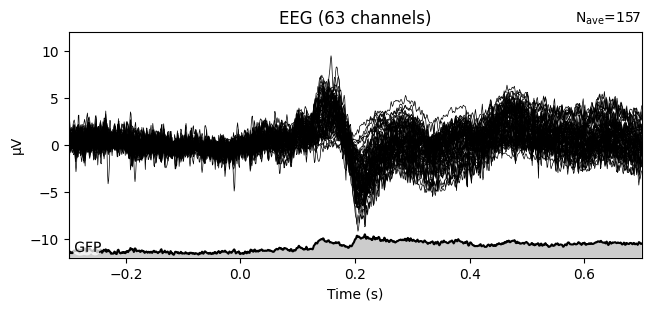

C:\Users\CSNDLab\AppData\Local\Temp\ipykernel_12648\3282695542.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evk.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-12, 12]))


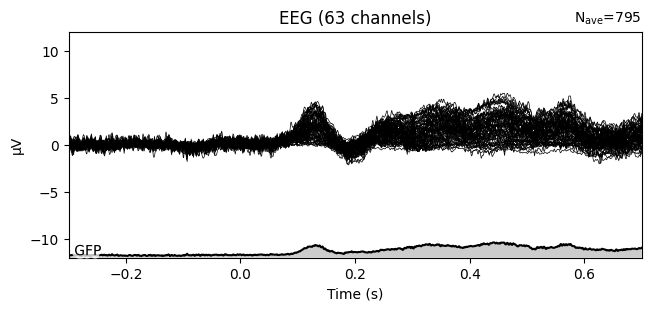

In [50]:
for evk in (devi_eps, sta_eps):
    evk.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-12, 12]))

combining channels using "mean"
combining channels using "mean"


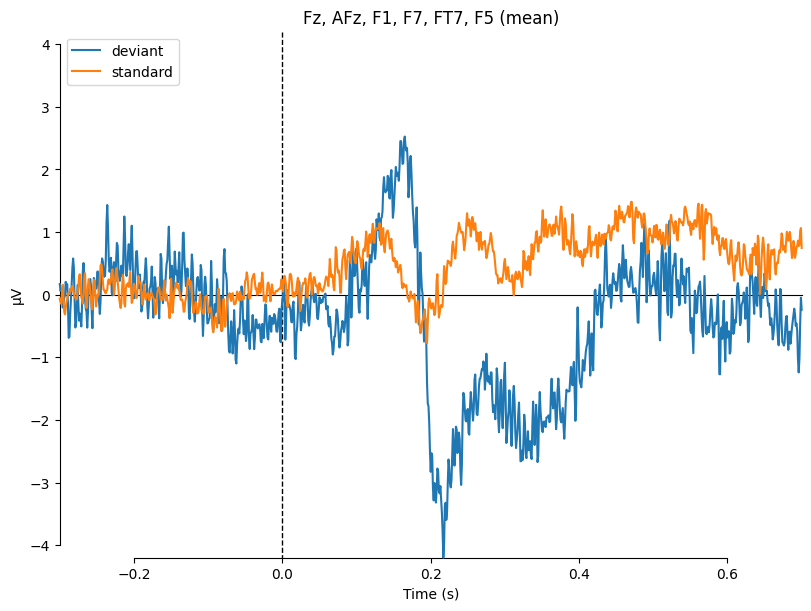

[<Figure size 800x600 with 1 Axes>]

In [51]:
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(deviant=devi_eps, standard=sta_eps)
picks = [1,34,35,3,37,36]
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"


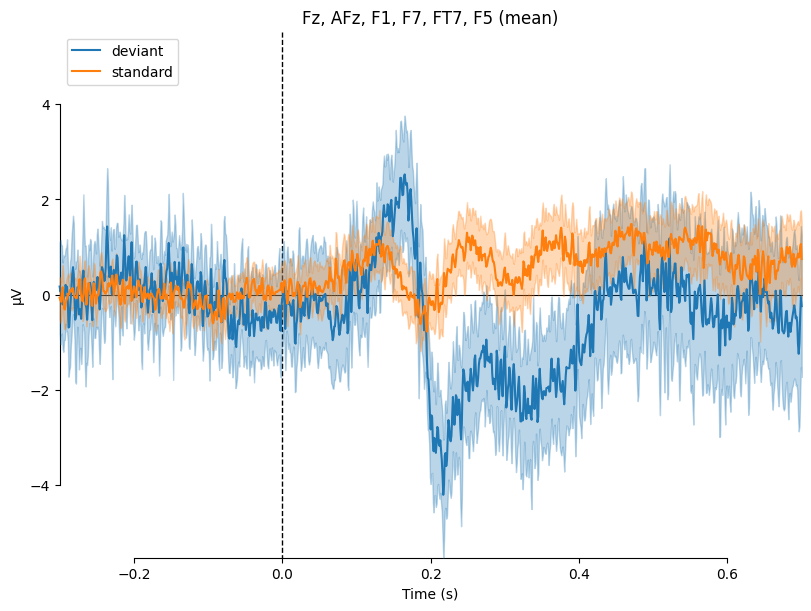

[<Figure size 800x600 with 1 Axes>]

In [52]:
# Campare the two contidition of deviant vs standard tone  with confidence interval 
evokeds = dict(
    deviant=list(B1_epochs['15'].iter_evoked()),
    standard=list(B1_epochs['14'].iter_evoked()),
    
)
mne.viz.plot_compare_evokeds(evokeds, combine="mean", picks=picks)

combining channels using "mean"


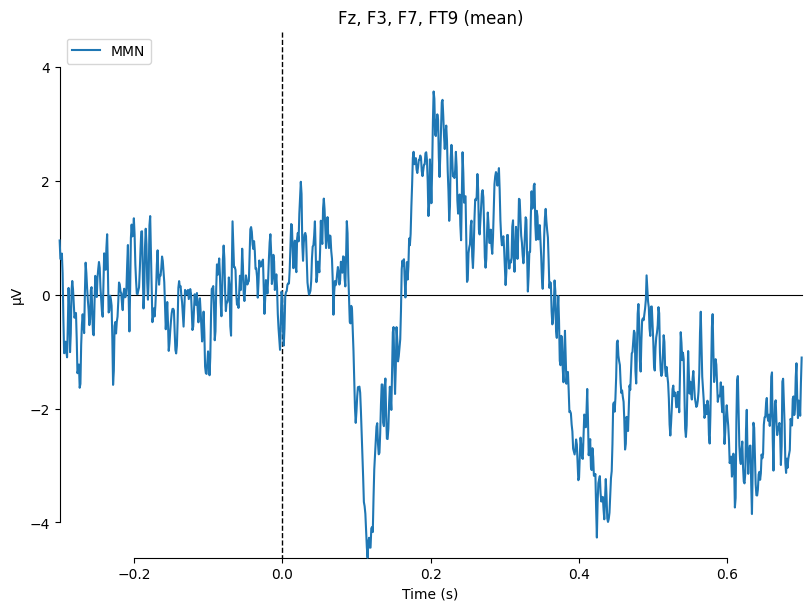

[<Figure size 800x600 with 1 Axes>]

In [29]:
MMN_erp = mne.combine_evoked([ devi_eps,sta_eps], weights=[-1, 1])
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(MMN = MMN_erp)
picks = [n for n in range(1, 5)]
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"


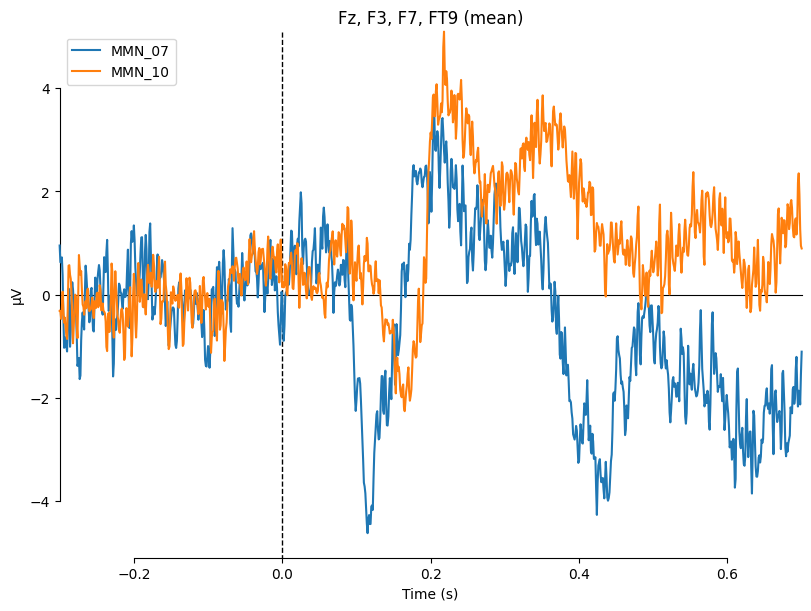

[<Figure size 800x600 with 1 Axes>]

In [54]:
MMN_erp1 = mne.combine_evoked([ devi_eps,sta_eps], weights=[-1, 1])
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(MMN_07 = MMN_erp,MMN_10 =MMN_erp1 )
picks = [n for n in range(1, 5)]
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

In [14]:
builtin_montages = mne.channels.get_builtin_montages(descriptions=True)
for montage_name, montage_description in builtin_montages:
    print(f"{montage_name}: {montage_description}")

standard_1005: Electrodes are named and positioned according to the international 10-05 system (343+3 locations)
standard_1020: Electrodes are named and positioned according to the international 10-20 system (94+3 locations)
standard_alphabetic: Electrodes are named with LETTER-NUMBER combinations (A1, B2, F4, …) (65+3 locations)
standard_postfixed: Electrodes are named according to the international 10-20 system using postfixes for intermediate positions (100+3 locations)
standard_prefixed: Electrodes are named according to the international 10-20 system using prefixes for intermediate positions (74+3 locations)
standard_primed: Electrodes are named according to the international 10-20 system using prime marks (' and '') for intermediate positions (100+3 locations)
biosemi16: BioSemi cap with 16 electrodes (16+3 locations)
biosemi32: BioSemi cap with 32 electrodes (32+3 locations)
biosemi64: BioSemi cap with 64 electrodes (64+3 locations)
biosemi128: BioSemi cap with 128 electrodes (1

Approximating Fpz location by mirroring Oz along the X and Y axes.


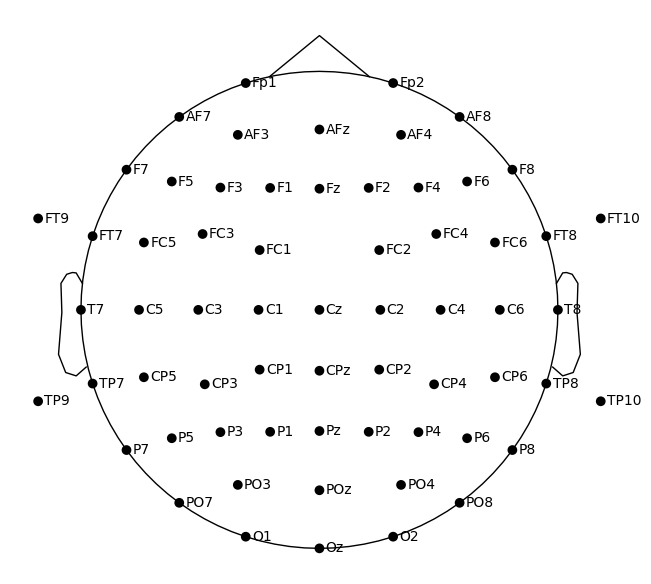

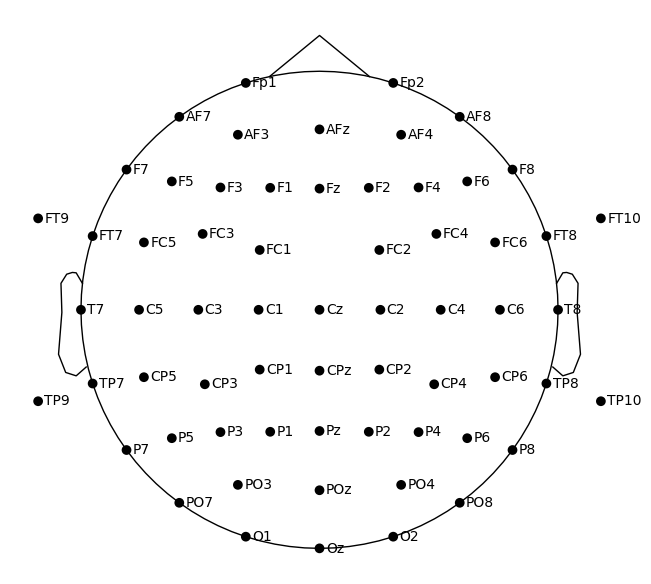

In [24]:
raw.set_montage("easycap-M1")
raw.plot_sensors(show_names=True, sphere="eeglab")